# Sleep Stage Prediction — Extended Paper Figures

This notebook generates a larger, publication-oriented figure set from the frozen project data and the final reported experiments.

**Data sources**
- `sleep_edf_features.csv`: 457,577 epochs, 16 columns
- `participant_split.csv`: 100 participants with participant-level train/validation/test split

**Important:** the notebook does not fabricate raw EEG waveforms or ROC curves. Figures that require predictions use the final reported test results/confusion matrix/AUC values already established for the project. Optional sections will use saved prediction/history files if they exist.

All figures are exported as both high-resolution PNG (300 dpi) and vector PDF to `paper_figures_extended/`.

In [3]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.autolayout': False,
})

DATA_DIR = Path('../data/features')
FEATURE_FILE = DATA_DIR / 'sleep_edf_features.csv'
SPLIT_FILE = DATA_DIR / 'participant_split.csv'
OUT_DIR = DATA_DIR / 'paper_figures_extended'
OUT_DIR.mkdir(parents=True, exist_ok=True)

STAGES = ['W', 'N1', 'N2', 'N3', 'REM']
FEATURES = [
    'delta_absolute', 'theta_absolute', 'alpha_absolute', 'beta_absolute',
    'delta_relative', 'theta_relative', 'alpha_relative', 'beta_relative',
    'spectral_entropy', 'dominant_frequency'
]
REL_FEATURES = ['delta_relative', 'theta_relative', 'alpha_relative', 'beta_relative']
ABS_FEATURES = ['delta_absolute', 'theta_absolute', 'alpha_absolute', 'beta_absolute']
DISPLAY_FEATURES = {
    'delta_absolute':'Delta absolute', 'theta_absolute':'Theta absolute',
    'alpha_absolute':'Alpha absolute', 'beta_absolute':'Beta absolute',
    'delta_relative':'Delta relative', 'theta_relative':'Theta relative',
    'alpha_relative':'Alpha relative', 'beta_relative':'Beta relative',
    'spectral_entropy':'Spectral entropy', 'dominant_frequency':'Dominant frequency'
}

def savefig(name):
    fig = plt.gcf()
    fig.savefig(OUT_DIR / f'{name}.png', dpi=300, bbox_inches='tight')
    fig.savefig(OUT_DIR / f'{name}.pdf', bbox_inches='tight')

def finish(name):
    plt.tight_layout()
    savefig(name)
    plt.show()

print('Output:', OUT_DIR.resolve())

Output: D:\Local Disk\Uni Sources\Term 8\Final Project\Sleep-Stage-Prediction\data\features\paper_figures_extended


In [4]:
df = pd.read_csv(FEATURE_FILE)
split_df = pd.read_csv(SPLIT_FILE)

# Participant ID is the first five characters of each Sleep-EDF recording ID (e.g. SC4001 -> SC400).
df['participant_id'] = df['subject_id'].astype(str).str[:5]
split_map = split_df[['participant_id','split']].drop_duplicates()
df = df.merge(split_map, on='participant_id', how='left', validate='many_to_one')

# Normalize naming used in some earlier files.
df['split'] = df['split'].replace({'val':'validation'})

assert df['target_stage'].isin(STAGES).all(), 'Unexpected stage label found.'
assert df['split'].isin(['train','validation','test']).all(), 'Missing or unexpected split labels.'

print(f'Feature rows: {len(df):,}')
print(f'Recordings: {df.subject_id.nunique():,}')
print(f'Participants: {df.participant_id.nunique():,}')
print(df['split'].value_counts())
print(df['target_stage'].value_counts().reindex(STAGES))

Feature rows: 457,577
Recordings: 197
Participants: 100
split
train         321688
test           70153
validation     65736
Name: count, dtype: int64
target_stage
W      289781
N1      25175
N2      88983
N3      19454
REM     34184
Name: count, dtype: int64


## Figure 1 — Overall sleep-stage distribution

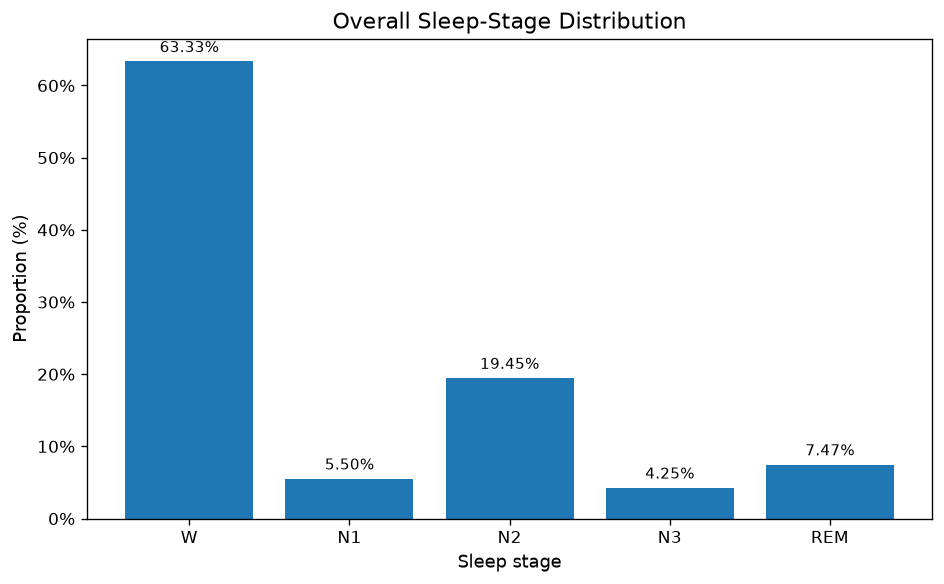

In [5]:
counts = df['target_stage'].value_counts().reindex(STAGES)
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(STAGES, pct)
ax.set_ylabel('Proportion (%)')
ax.set_xlabel('Sleep stage')
ax.set_title('Overall Sleep-Stage Distribution')
ax.yaxis.set_major_formatter(PercentFormatter(100))
for b, v in zip(bars, pct):
    ax.text(b.get_x()+b.get_width()/2, v+0.8, f'{v:.2f}%', ha='center', va='bottom', fontsize=9)
finish('fig01_overall_class_distribution')

## Figure 2 — Class proportions across data splits

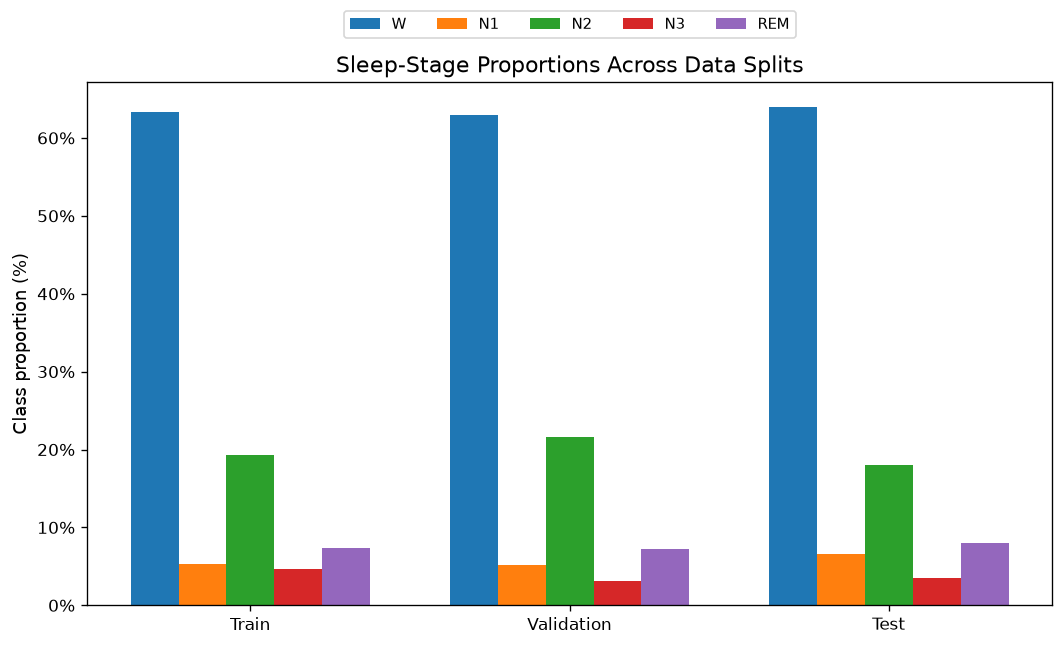

In [6]:
tab = pd.crosstab(df['split'], df['target_stage'], normalize='index').reindex(['train','validation','test']).reindex(columns=STAGES) * 100

fig, ax = plt.subplots(figsize=(9,5.5))
x = np.arange(3)
width = 0.15
for j, stage in enumerate(STAGES):
    ax.bar(x + (j-2)*width, tab[stage].values, width, label=stage)
ax.set_xticks(x, ['Train','Validation','Test'])
ax.set_ylabel('Class proportion (%)')
ax.set_title('Sleep-Stage Proportions Across Data Splits')
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.legend(ncol=5, loc='upper center', bbox_to_anchor=(0.5,1.15))
finish('fig02_split_class_proportions')

## Figure 3 — Absolute class counts (log scale)

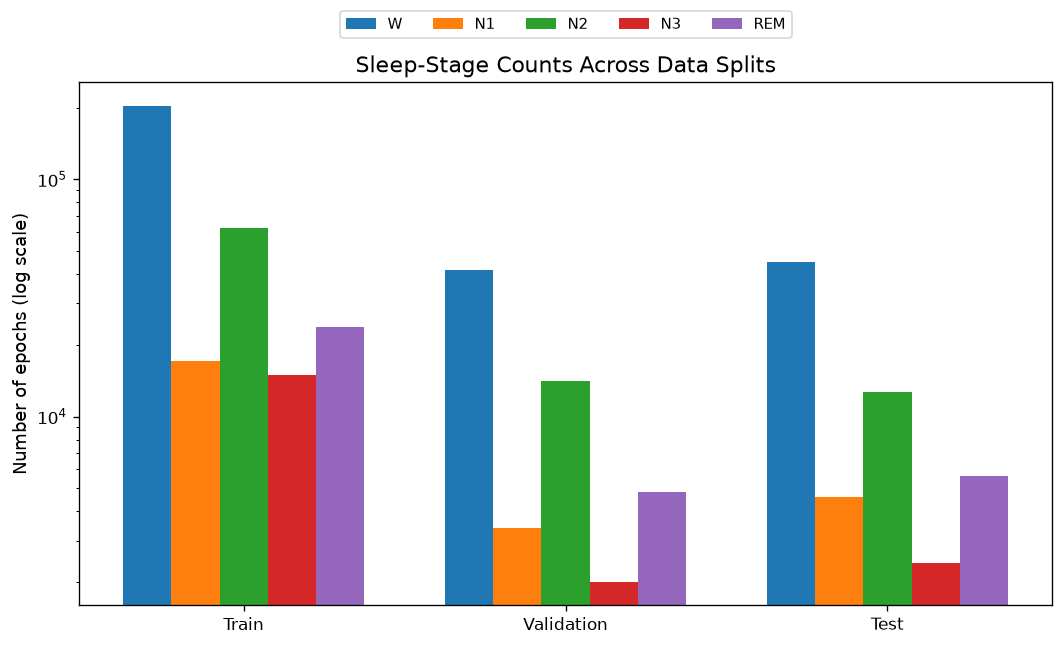

In [7]:
tabc = pd.crosstab(df['split'], df['target_stage']).reindex(['train','validation','test']).reindex(columns=STAGES)

fig, ax = plt.subplots(figsize=(9,5.5))
x = np.arange(3)
width = 0.15
for j, stage in enumerate(STAGES):
    bars=ax.bar(x+(j-2)*width, tabc[stage].values, width, label=stage)
ax.set_xticks(x, ['Train','Validation','Test'])
ax.set_yscale('log')
ax.set_ylabel('Number of epochs (log scale)')
ax.set_title('Sleep-Stage Counts Across Data Splits')
ax.legend(ncol=5, loc='upper center', bbox_to_anchor=(0.5,1.15))
finish('fig03_split_class_counts_log')

## Figure 4 — Relative band power by sleep stage

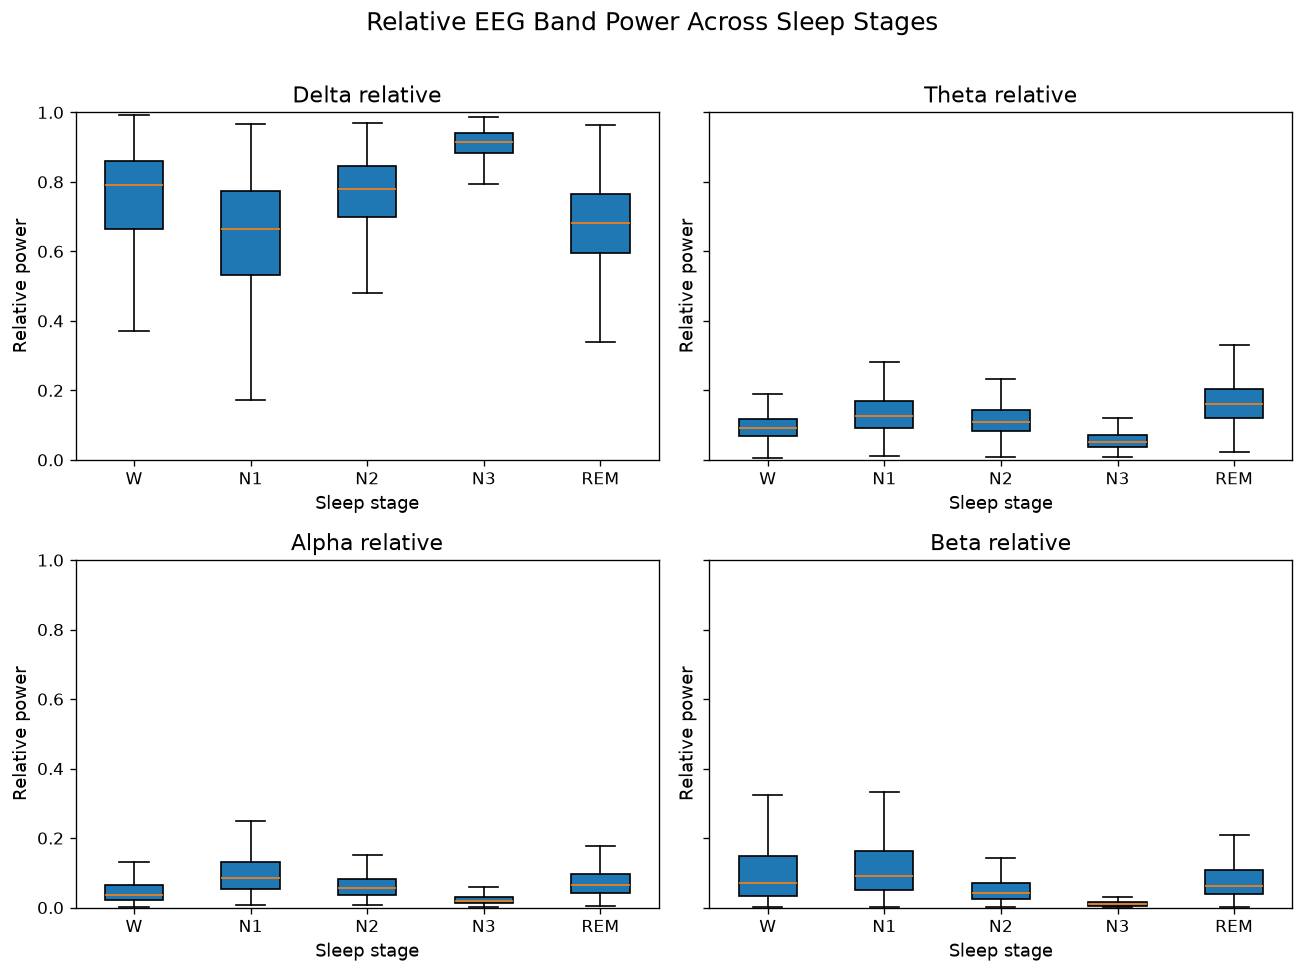

In [64]:
sample_parts=[]
for stage in STAGES:
    g=df[df.target_stage==stage]
    sample_parts.append(g.sample(min(4000,len(g)), random_state=42))
samp=pd.concat(sample_parts, ignore_index=True)

fig, axes=plt.subplots(2,2,figsize=(11,8),sharey=True)
for ax, feat in zip(axes.flat, REL_FEATURES):
    data=[samp.loc[samp.target_stage==st, feat].dropna().values for st in STAGES]
    ax.boxplot(data, tick_labels=STAGES, patch_artist=True, showfliers=False)
    ax.set_title(DISPLAY_FEATURES[feat])
    ax.set_xlabel('Sleep stage')
    ax.set_ylabel('Relative power')
    ax.set_ylim(0,1)
fig.suptitle('Relative EEG Band Power Across Sleep Stages', y=1.01, fontsize=15)
finish('fig04_relative_band_power_by_stage')

## Figure 5 — Absolute band power (log10) by sleep stage

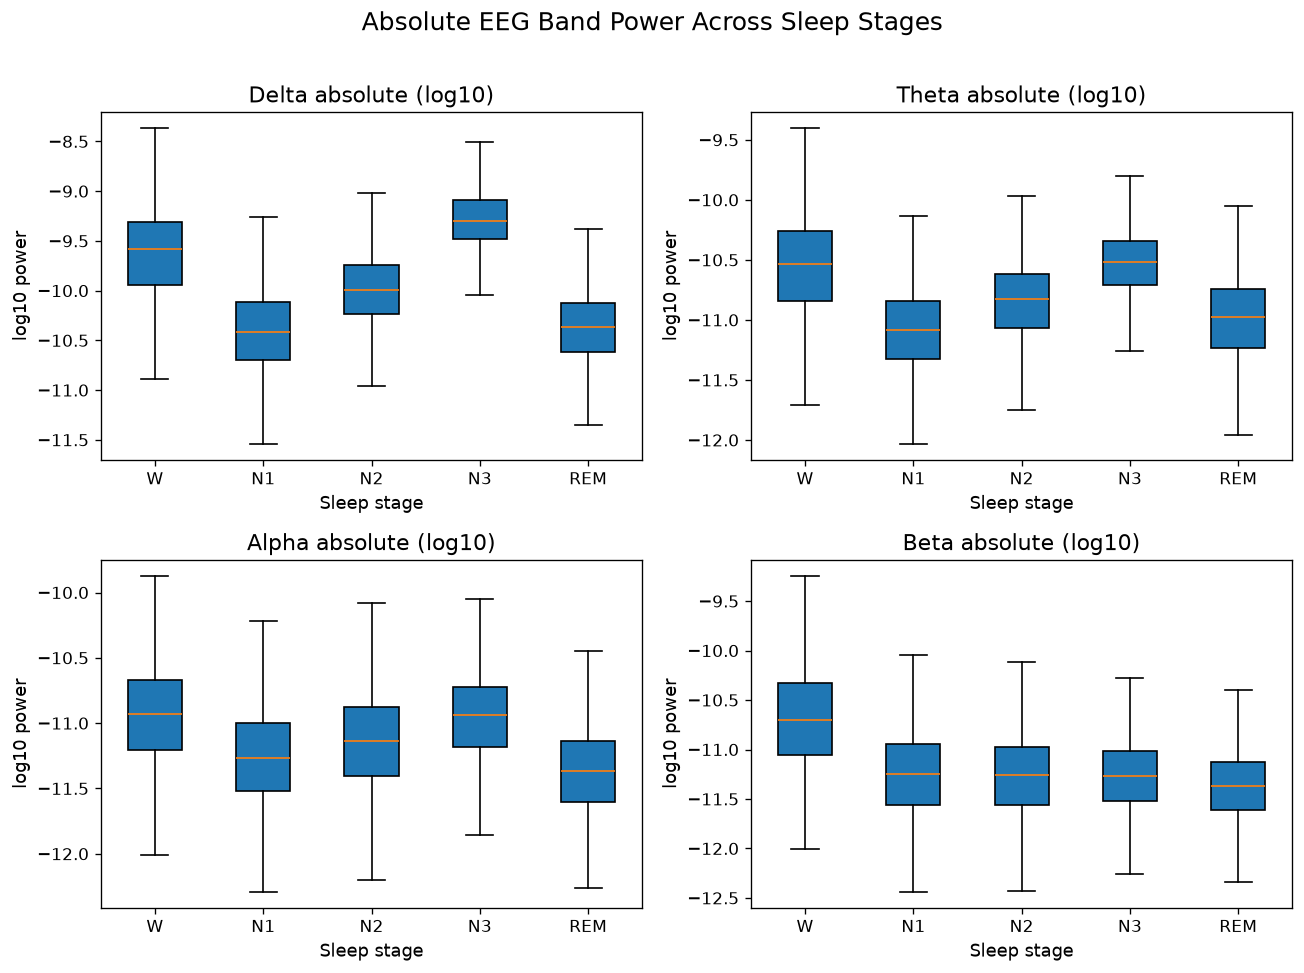

In [65]:
for feat in ABS_FEATURES:
    samp[feat+'_log10'] = np.log10(np.clip(samp[feat], 1e-30, None))

fig, axes=plt.subplots(2,2,figsize=(11,8),sharey=False)
for ax, feat in zip(axes.flat, ABS_FEATURES):
    data=[samp.loc[samp.target_stage==st, feat+'_log10'].dropna().values for st in STAGES]
    ax.boxplot(data, tick_labels=STAGES, patch_artist=True, showfliers=False)
    ax.set_title(DISPLAY_FEATURES[feat]+' (log10)')
    ax.set_xlabel('Sleep stage')
    ax.set_ylabel('log10 power')
fig.suptitle('Absolute EEG Band Power Across Sleep Stages', y=1.01, fontsize=15)
finish('fig05_absolute_band_power_log10')

## Figure 6 — Spectral entropy by sleep stage

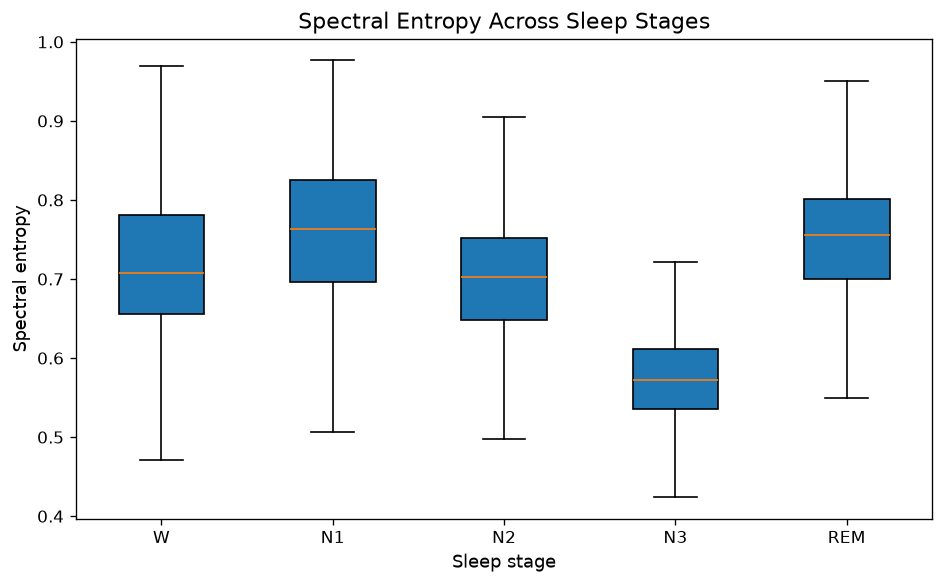

In [66]:
fig, ax=plt.subplots(figsize=(8,5))
data=[samp.loc[samp.target_stage==st,'spectral_entropy'].dropna().values for st in STAGES]
ax.boxplot(data, tick_labels=STAGES, patch_artist=True, showfliers=False)
ax.set_xlabel('Sleep stage'); ax.set_ylabel('Spectral entropy'); ax.set_title('Spectral Entropy Across Sleep Stages')
finish('fig06_spectral_entropy_by_stage')

## Figure 7 — Dominant frequency by sleep stage

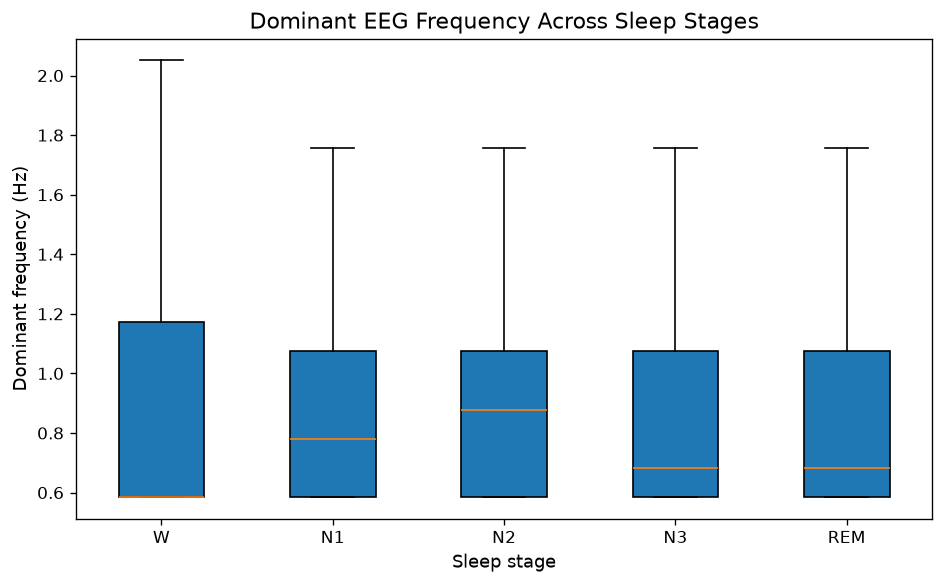

In [67]:
fig, ax=plt.subplots(figsize=(8,5))
data=[samp.loc[samp.target_stage==st,'dominant_frequency'].dropna().values for st in STAGES]
ax.boxplot(data, tick_labels=STAGES, patch_artist=True, showfliers=False)
ax.set_xlabel('Sleep stage'); ax.set_ylabel('Dominant frequency (Hz)'); ax.set_title('Dominant EEG Frequency Across Sleep Stages')
finish('fig07_dominant_frequency_by_stage')

## Figure 8 — Stage-wise standardized feature medians

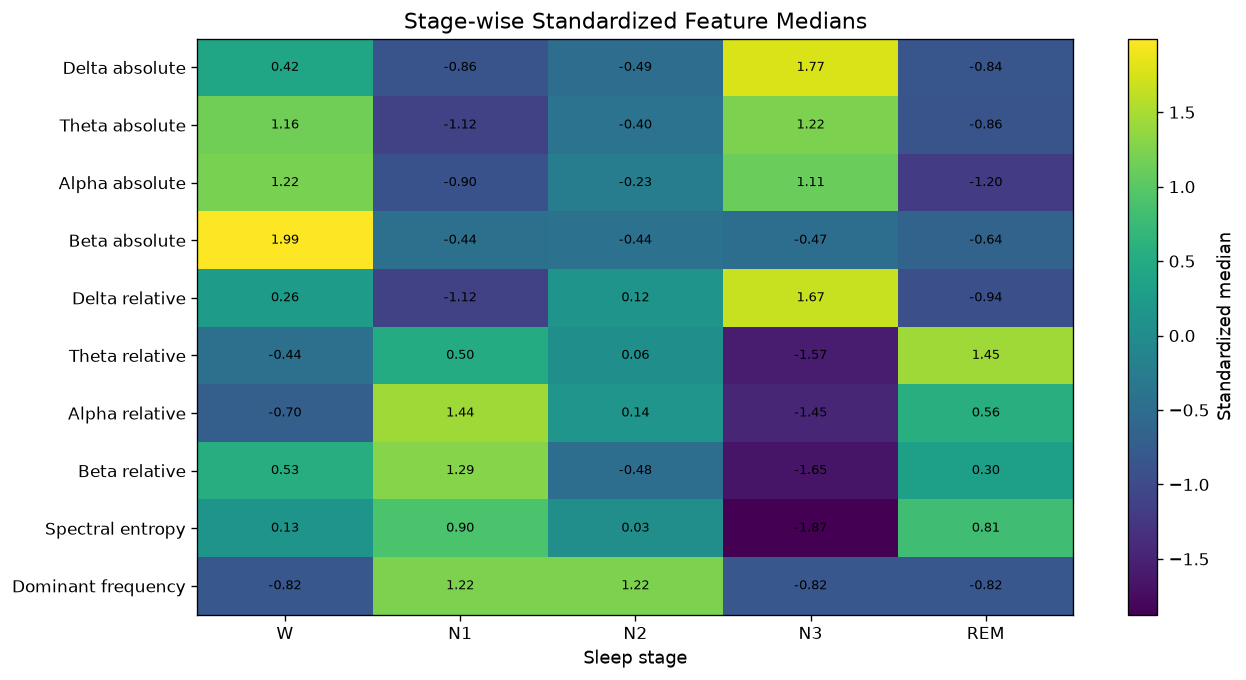

In [15]:
med = df.groupby('target_stage')[FEATURES].median().reindex(STAGES)
med_z = (med - med.mean(axis=0)) / med.std(axis=0, ddof=0).replace(0,1)

fig, ax = plt.subplots(figsize=(11,5.8))
im=ax.imshow(med_z.T, aspect='auto')
ax.set_xticks(range(len(STAGES)), STAGES)
ax.set_yticks(range(len(FEATURES)), [DISPLAY_FEATURES[f] for f in FEATURES])
ax.set_title('Stage-wise Standardized Feature Medians')
ax.set_xlabel('Sleep stage')
fig.colorbar(im, ax=ax, label='Standardized median')
for i in range(len(FEATURES)):
    for j in range(len(STAGES)):
        ax.text(j,i,f'{med_z.iloc[j,i]:.2f}',ha='center',va='center',fontsize=8)
finish('fig08_stage_feature_median_heatmap')

## Figure 9 — Correlation among engineered features

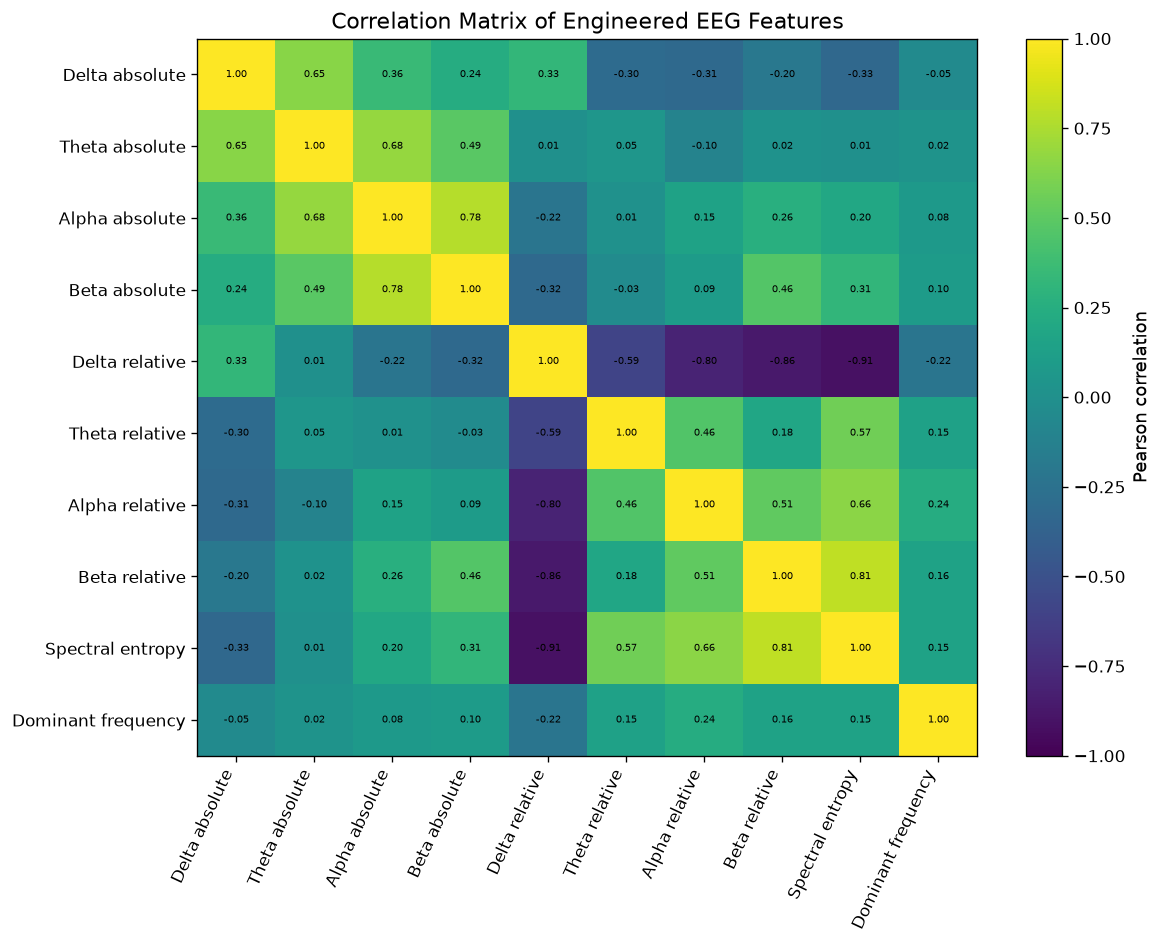

In [16]:
corr = df[FEATURES].corr()
fig, ax=plt.subplots(figsize=(10,8))
im=ax.imshow(corr, vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(FEATURES)), [DISPLAY_FEATURES[f] for f in FEATURES], rotation=65, ha='right')
ax.set_yticks(range(len(FEATURES)), [DISPLAY_FEATURES[f] for f in FEATURES])
ax.set_title('Correlation Matrix of Engineered EEG Features')
fig.colorbar(im, ax=ax, label='Pearson correlation')
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',fontsize=6)
finish('fig09_feature_correlation_matrix')

## Figure 10 — PCA projection of the engineered feature space

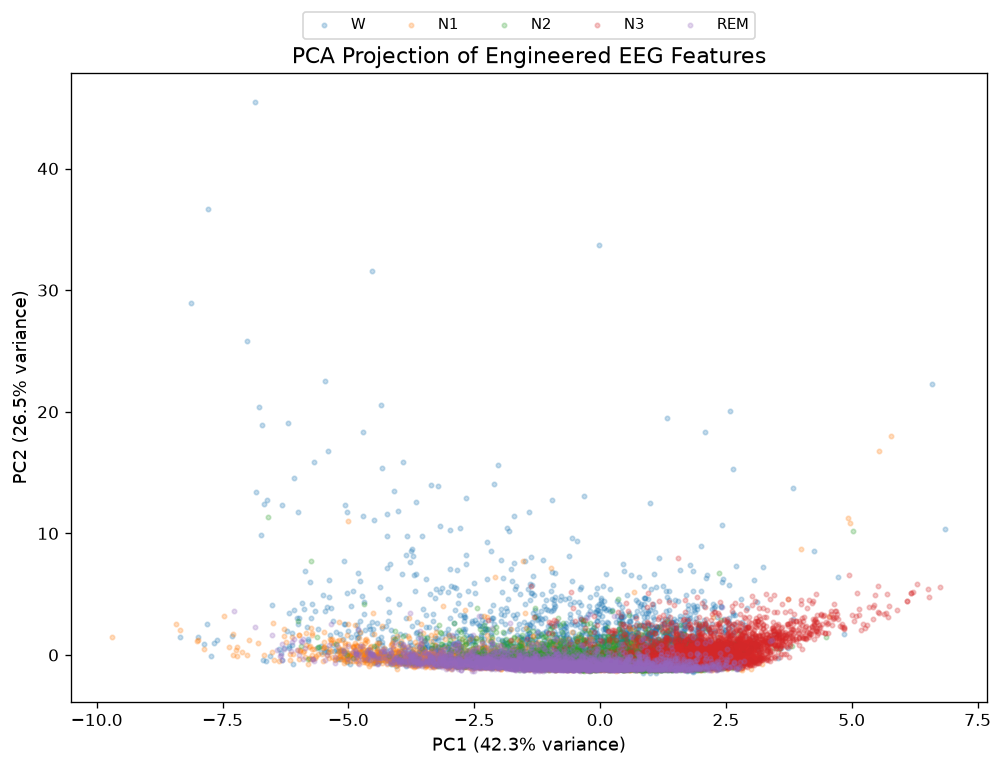

In [17]:
pca_parts=[]
for stage in STAGES:
    g=df[df.target_stage==stage]
    pca_parts.append(g.sample(min(3000,len(g)), random_state=123))
pca_df=pd.concat(pca_parts, ignore_index=True)
X=StandardScaler().fit_transform(pca_df[FEATURES])
pca=PCA(n_components=2, random_state=42)
Z=pca.fit_transform(X)

fig, ax=plt.subplots(figsize=(8.5,6.5))
for st in STAGES:
    m=pca_df.target_stage.values==st
    ax.scatter(Z[m,0], Z[m,1], s=7, alpha=.25, label=st)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('PCA Projection of Engineered EEG Features')
ax.legend(ncol=5, loc='upper center', bbox_to_anchor=(0.5,1.11))
finish('fig10_pca_feature_space')

## Figure 11 — Distribution of all engineered features by stage

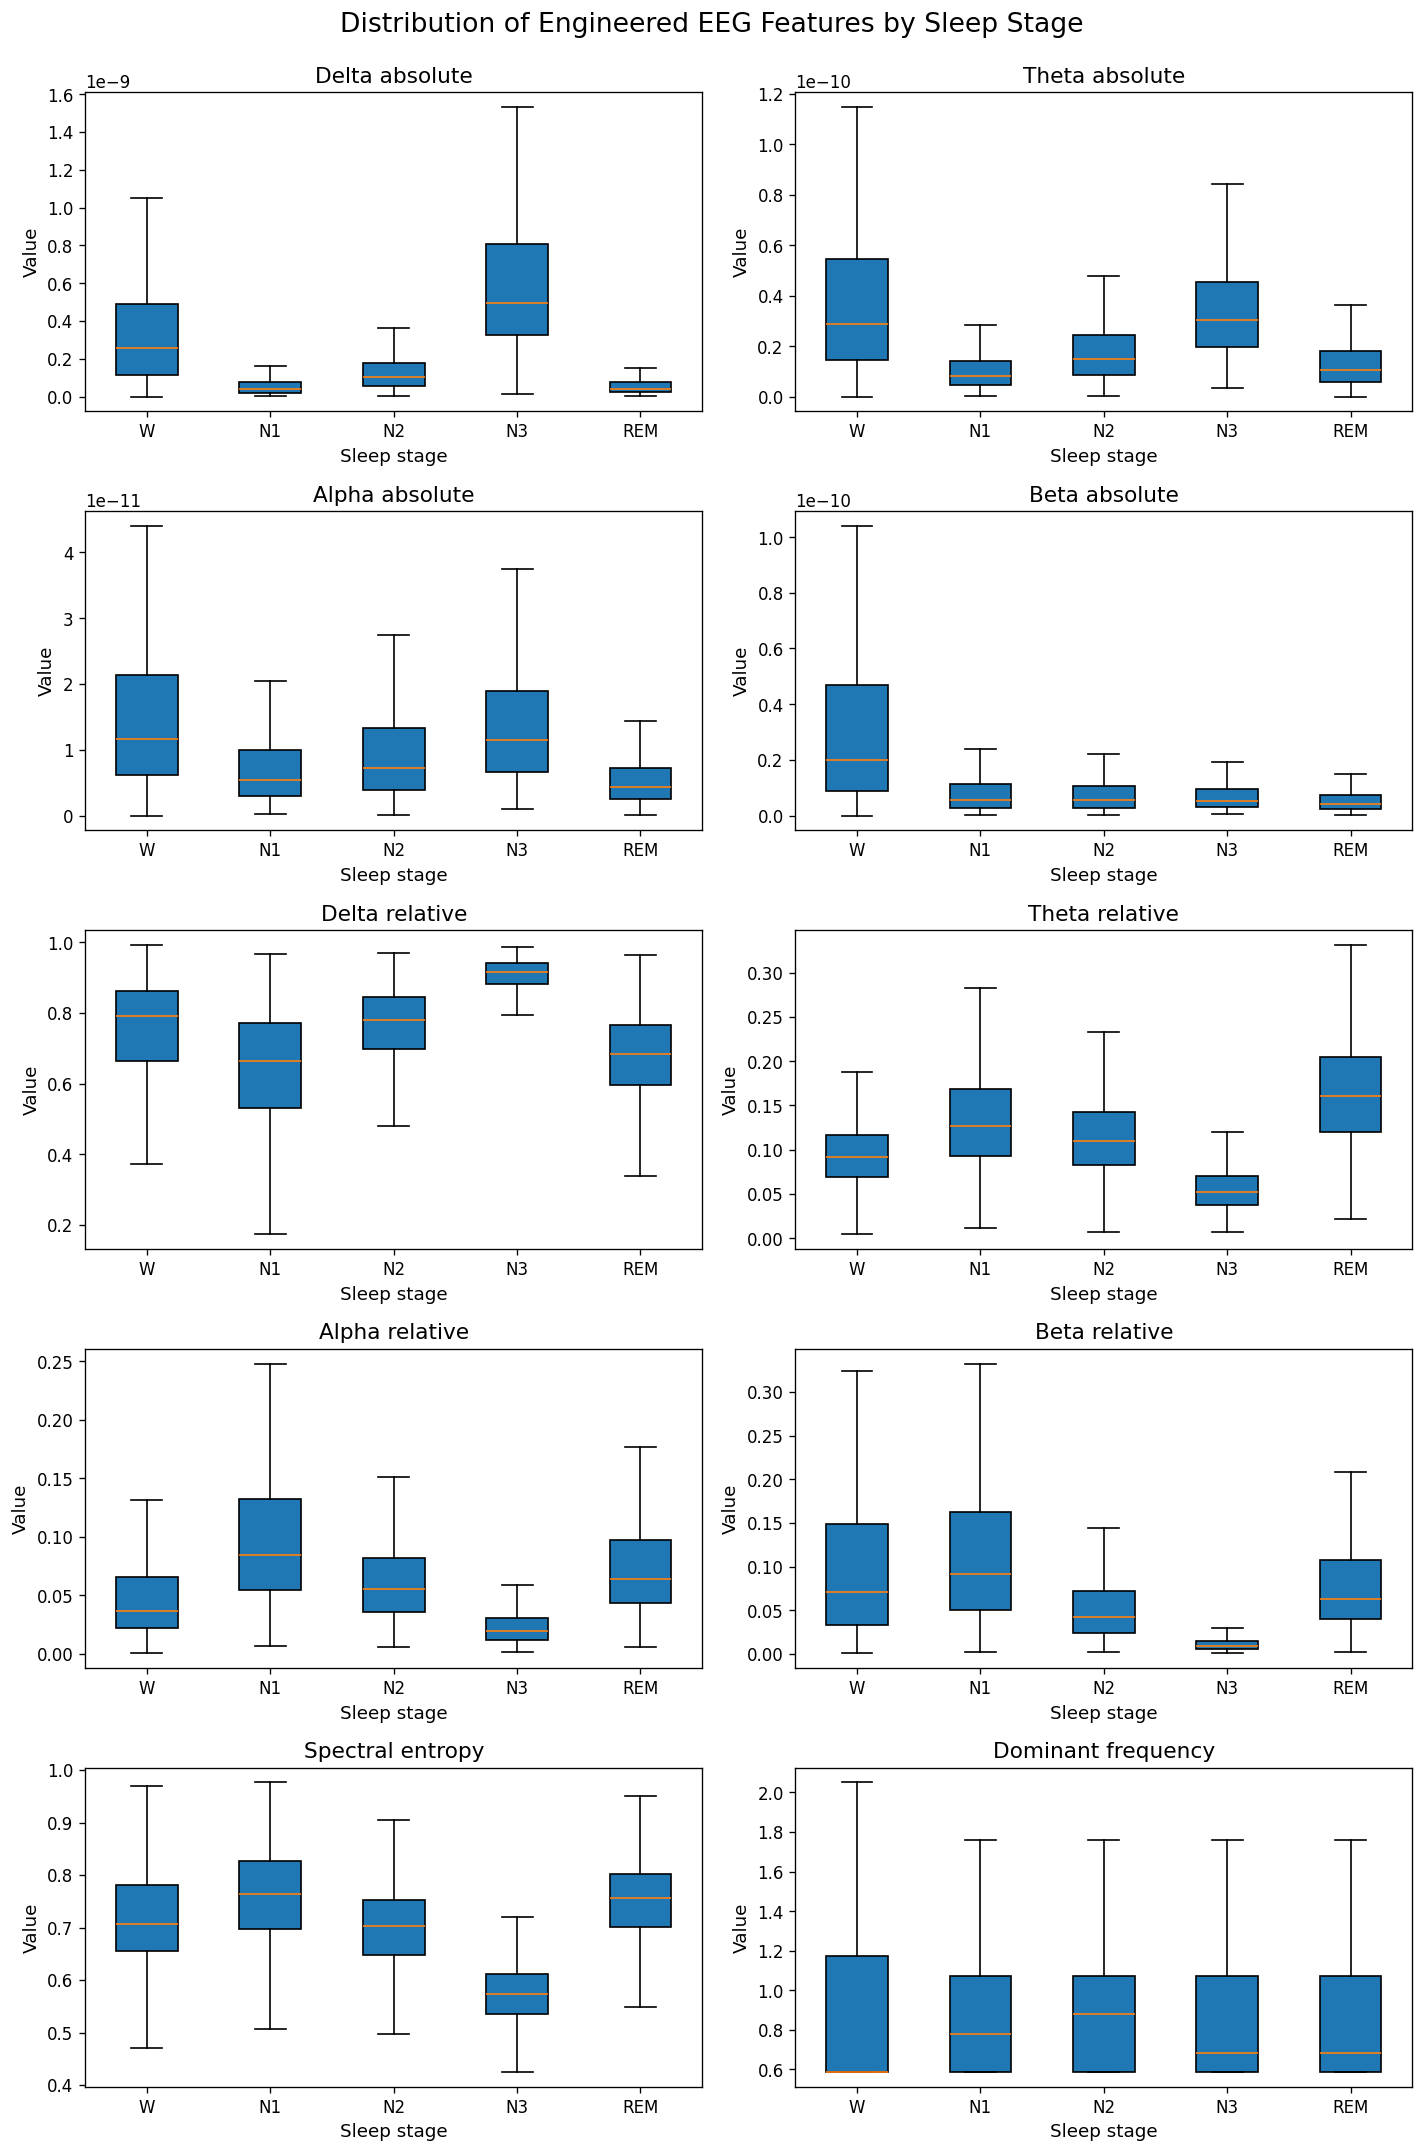

In [13]:
fig, axes=plt.subplots(5,2,figsize=(12,18))
for ax, feat in zip(axes.flat, FEATURES):
    data=[samp.loc[samp.target_stage==st, feat].dropna().values for st in STAGES]
    ax.boxplot(data, labels=STAGES, showfliers=False, patch_artist=True)
    ax.set_title(DISPLAY_FEATURES[feat])
    ax.set_xlabel('Sleep stage')
    ax.set_ylabel('Value')
fig.suptitle('Distribution of Engineered EEG Features by Sleep Stage', y=0.995, fontsize=16)
finish('fig11_all_feature_distributions')

## Final reported experiment tables

The following values are the frozen project results used for the thesis. They are entered explicitly so the figures remain reproducible even when raw training-history files are not present.

In [18]:
context = pd.DataFrame({
    'Context':['2.5 min (5 epochs)','5 min (10 epochs)','10 min (20 epochs)'],
    'Accuracy':[0.8292,0.8497,0.8513],
    'Balanced Accuracy':[0.6572,0.6824,0.6828],
    'Macro-F1':[0.6366,0.6749,0.6733]
})
loss = pd.DataFrame({
    'Loss':['Unweighted','Moderated class-weighted','Weighted'],
    'Accuracy':[0.8497,0.8278,0.7917],
    'Balanced Accuracy':[0.6824,0.7283,0.7510],
    'Macro-F1':[0.6749,0.6701,0.6428]
})
capacity = pd.DataFrame({
    'LSTM units':['32','64','128'],
    'Accuracy':[0.8497,0.8458,0.8161],
    'Balanced Accuracy':[0.6824,0.6774,0.6582],
    'Macro-F1':[0.6749,0.6721,0.6393]
})
architecture = pd.DataFrame({
    'Architecture':['Single LSTM','Stacked LSTM','Bidirectional LSTM','Attention LSTM'],
    'Accuracy':[0.8497,0.8577,0.8324,0.8401],
    'Balanced Accuracy':[0.6824,0.6875,0.6681,0.6760],
    'Macro-F1':[0.6749,0.6869,0.6554,0.6627]
})
seeds = pd.DataFrame({
    'Seed':[42,123,456],
    'Accuracy':[0.8266,0.8224,0.8230],
    'Balanced Accuracy':[0.6517,0.6537,0.6565],
    'Macro Precision':[0.6706,0.6661,0.6627],
    'Macro Recall':[0.6517,0.6537,0.6565],
    'Macro-F1':[0.6534,0.6520,0.6524],
    'Weighted-F1':[0.8245,0.8221,0.8235],
    'Kappa':[0.6852,0.6794,0.6823]
})
per_class = pd.DataFrame({
    'Stage':STAGES,
    'F1':[0.9472,0.3419,0.6957,0.7309,0.5472],
    'Precision':[0.9622,0.4683,0.6348,0.7694,0.5185],
    'Recall':[0.9353,0.2634,0.7758,0.7052,0.5790],
})
auc = pd.DataFrame({
    'Stage':STAGES,
    'ROC-AUC':[0.9813,0.8964,0.9384,0.9883,0.9205]
})

## Figure 12 — Temporal context ablation

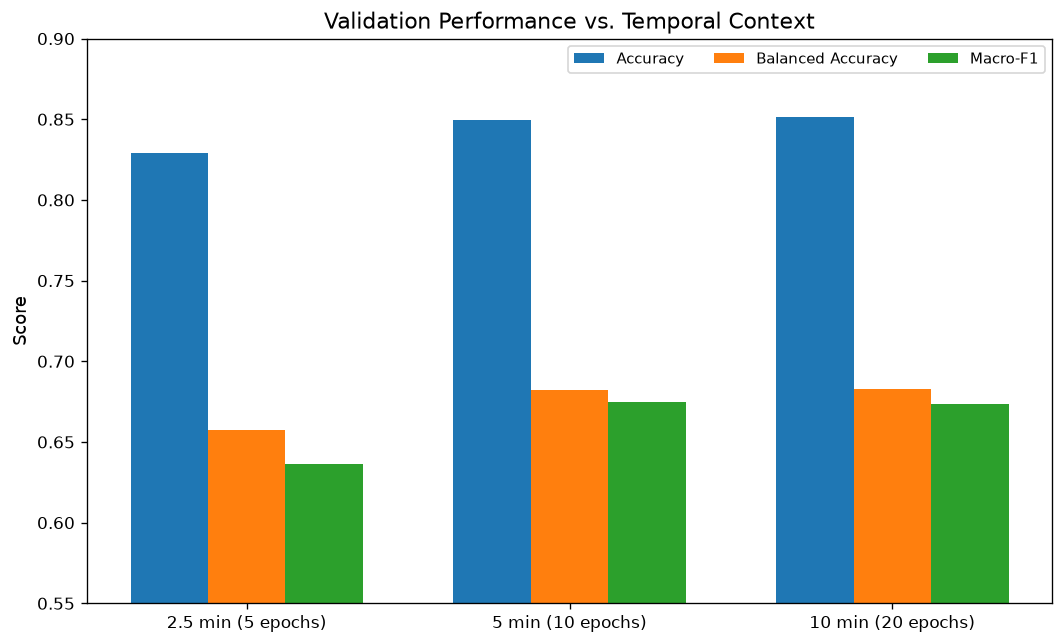

In [19]:
fig, ax=plt.subplots(figsize=(9,5.5))
x=np.arange(len(context)); w=.24
for j,m in enumerate(['Accuracy','Balanced Accuracy','Macro-F1']): ax.bar(x+(j-1)*w, context[m], w, label=m)
ax.set_xticks(x, context['Context']); ax.set_ylim(.55,.9); ax.set_ylabel('Score'); ax.set_title('Validation Performance vs. Temporal Context'); ax.legend(ncol=3)
finish('fig12_context_ablation')

## Figure 13 — Loss / class-weighting ablation

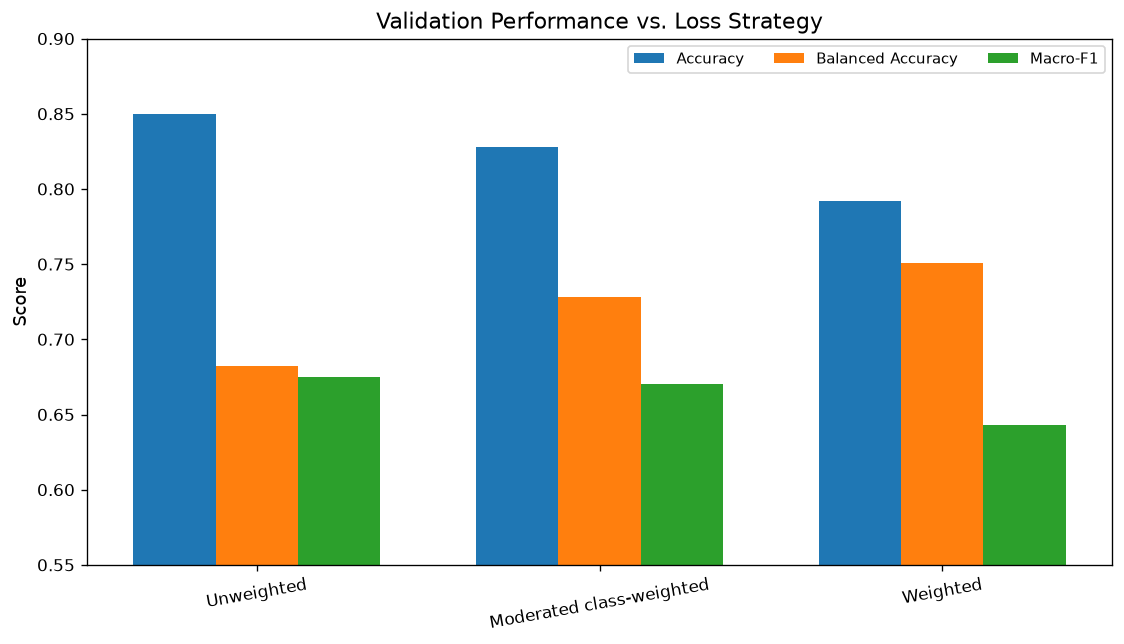

In [79]:
fig, ax=plt.subplots(figsize=(9.5,5.5))
x=np.arange(len(loss)); w=.24
for j,m in enumerate(['Accuracy','Balanced Accuracy','Macro-F1']): ax.bar(x+(j-1)*w, loss[m], w, label=m)
ax.set_xticks(x, loss['Loss'], rotation=10); ax.set_ylim(.55,.9); ax.set_ylabel('Score'); ax.set_title('Validation Performance vs. Loss Strategy'); ax.legend(ncol=3)
finish('fig13_loss_ablation')

## Figure 14 — LSTM capacity ablation

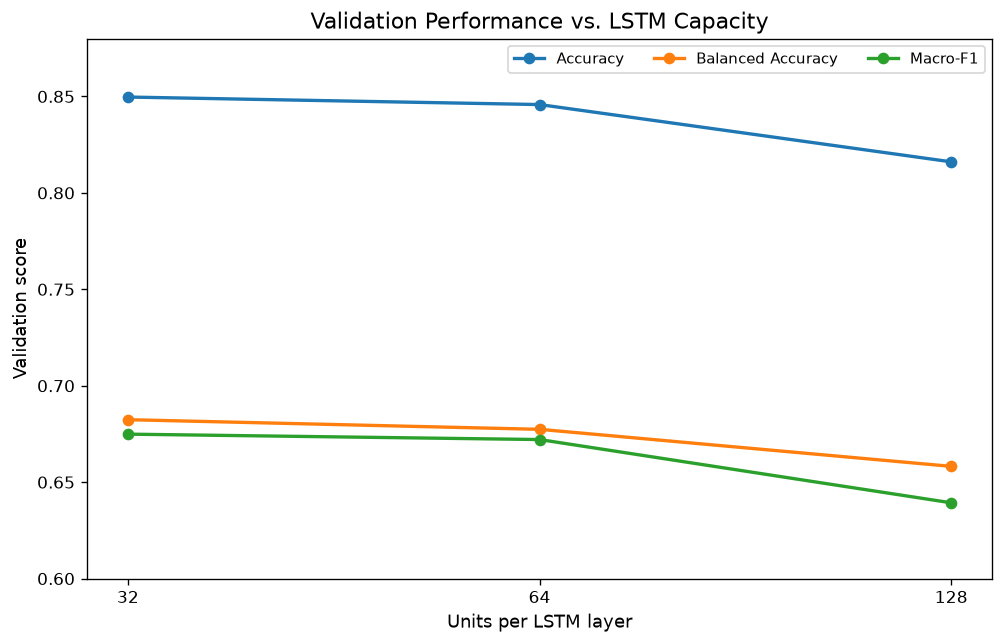

In [21]:
fig, ax=plt.subplots(figsize=(8.5,5.5))
x=np.arange(len(capacity)); w=.24
for j,m in enumerate(['Accuracy','Balanced Accuracy','Macro-F1']): ax.plot(x, capacity[m], marker='o', linewidth=2, label=m)
ax.set_xticks(x, capacity['LSTM units']); ax.set_xlabel('Units per LSTM layer'); ax.set_ylim(.60,.88); ax.set_ylabel('Validation score'); ax.set_title('Validation Performance vs. LSTM Capacity'); ax.legend(ncol=3)
finish('fig14_lstm_capacity_ablation')

## Figure 15 — LSTM architecture comparison

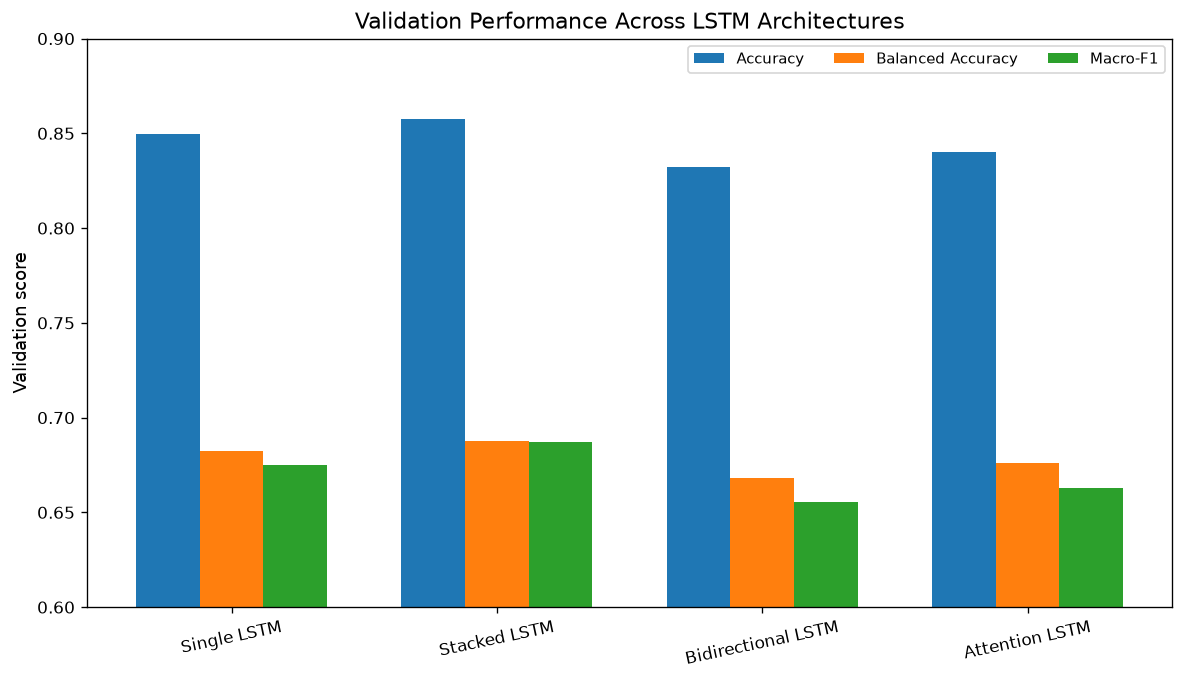

In [22]:
fig, ax=plt.subplots(figsize=(10,5.8))
x=np.arange(len(architecture)); w=.24
for j,m in enumerate(['Accuracy','Balanced Accuracy','Macro-F1']): ax.bar(x+(j-1)*w, architecture[m], w, label=m)
ax.set_xticks(x, architecture['Architecture'], rotation=12); ax.set_ylim(.60,.9); ax.set_ylabel('Validation score'); ax.set_title('Validation Performance Across LSTM Architectures'); ax.legend(ncol=3)
finish('fig15_architecture_comparison')

## Figure 16 — Macro-F1 summary of the major ablations

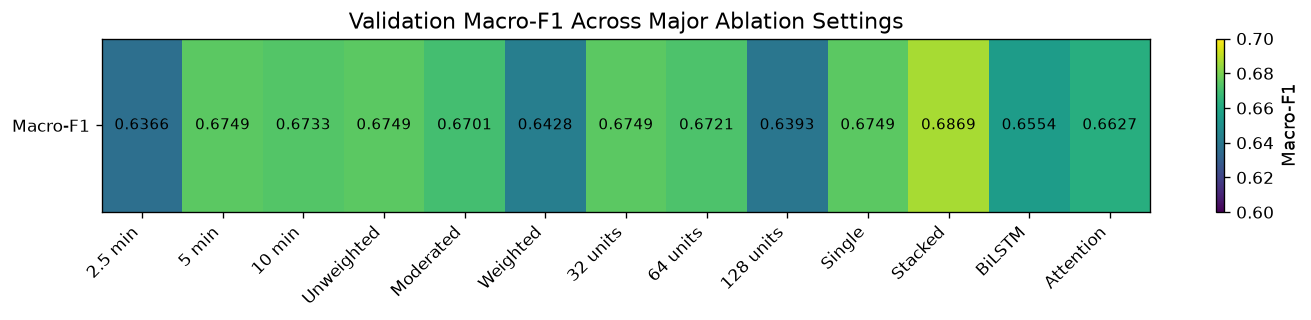

In [23]:
ab = pd.DataFrame({
    '2.5 min':[context.loc[0,'Macro-F1']], '5 min':[context.loc[1,'Macro-F1']], '10 min':[context.loc[2,'Macro-F1']],
    'Unweighted':[loss.loc[0,'Macro-F1']], 'Moderated':[loss.loc[1,'Macro-F1']], 'Weighted':[loss.loc[2,'Macro-F1']],
    '32 units':[capacity.loc[0,'Macro-F1']], '64 units':[capacity.loc[1,'Macro-F1']], '128 units':[capacity.loc[2,'Macro-F1']],
    'Single':[architecture.loc[0,'Macro-F1']], 'Stacked':[architecture.loc[1,'Macro-F1']], 'BiLSTM':[architecture.loc[2,'Macro-F1']], 'Attention':[architecture.loc[3,'Macro-F1']]
}, index=['Macro-F1'])
fig, ax=plt.subplots(figsize=(12,2.8))
im=ax.imshow(ab.values, aspect='auto', vmin=.60, vmax=.70)
ax.set_xticks(range(ab.shape[1]), ab.columns, rotation=45, ha='right')
ax.set_yticks([0], ['Macro-F1'])
for j,v in enumerate(ab.values[0]): ax.text(j,0,f'{v:.4f}',ha='center',va='center',fontsize=9)
ax.set_title('Validation Macro-F1 Across Major Ablation Settings')
fig.colorbar(im, ax=ax, label='Macro-F1')
finish('fig16_ablation_macrof1_summary')

## Figure 17 — Seed robustness

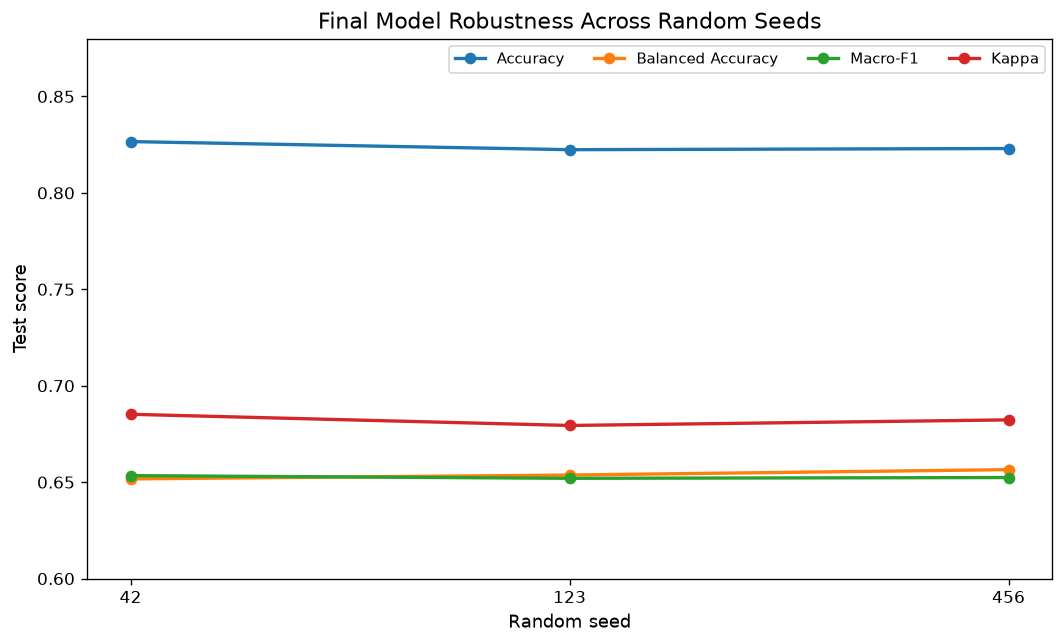

In [24]:
fig, ax=plt.subplots(figsize=(9,5.5))
metrics=['Accuracy','Balanced Accuracy','Macro-F1','Kappa']
for m in metrics: ax.plot(seeds['Seed'].astype(str), seeds[m], marker='o', linewidth=2, label=m)
ax.set_xlabel('Random seed'); ax.set_ylabel('Test score'); ax.set_ylim(.60,.88); ax.set_title('Final Model Robustness Across Random Seeds'); ax.legend(ncol=4)
finish('fig17_seed_robustness')

## Figure 18 — Per-stage F1-score

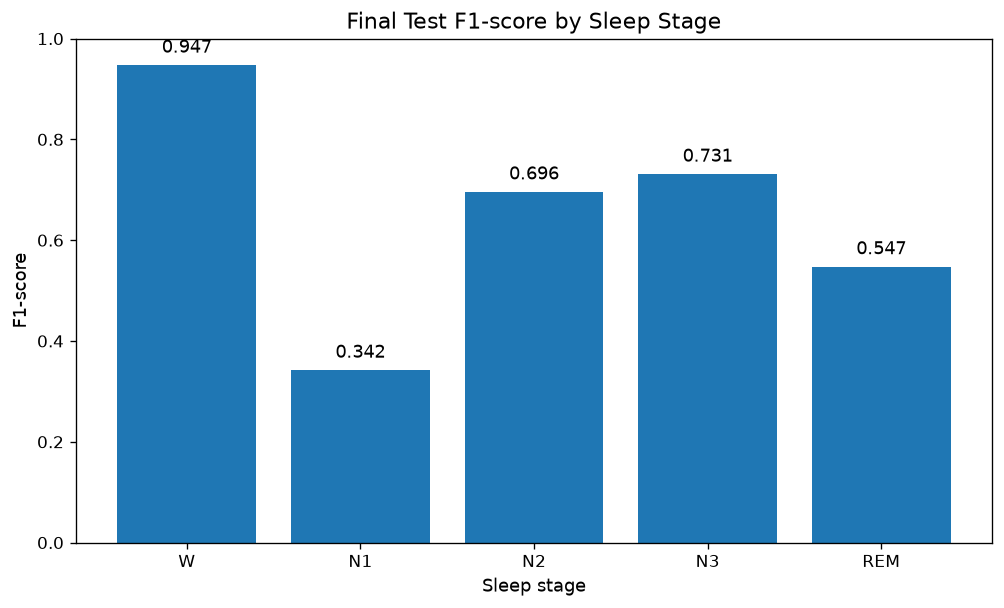

In [25]:
fig, ax=plt.subplots(figsize=(8.5,5.2))
b=ax.bar(per_class.Stage, per_class.F1)
ax.set_ylim(0,1); ax.set_ylabel('F1-score'); ax.set_xlabel('Sleep stage'); ax.set_title('Final Test F1-score by Sleep Stage')
for bar,v in zip(b,per_class.F1): ax.text(bar.get_x()+bar.get_width()/2,v+.025,f'{v:.3f}',ha='center')
finish('fig18_per_stage_f1')

## Figure 19 — Per-stage precision and recall

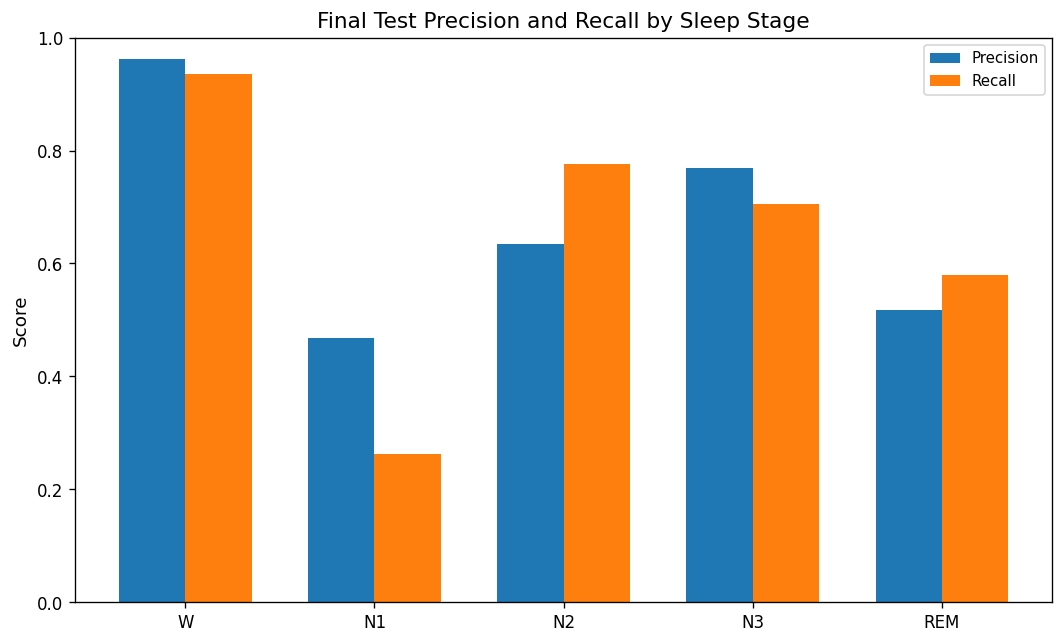

In [22]:
fig, ax=plt.subplots(figsize=(9,5.5))
x=np.arange(len(STAGES)); w=.35
ax.bar(x-w/2, per_class.Precision, w, label='Precision')
ax.bar(x+w/2, per_class.Recall, w, label='Recall')
ax.set_xticks(x, STAGES); ax.set_ylim(0,1); ax.set_ylabel('Score'); ax.set_title('Final Test Precision and Recall by Sleep Stage'); ax.legend()
finish('fig19_precision_recall_by_stage')

## Figure 20 — Per-stage ROC-AUC

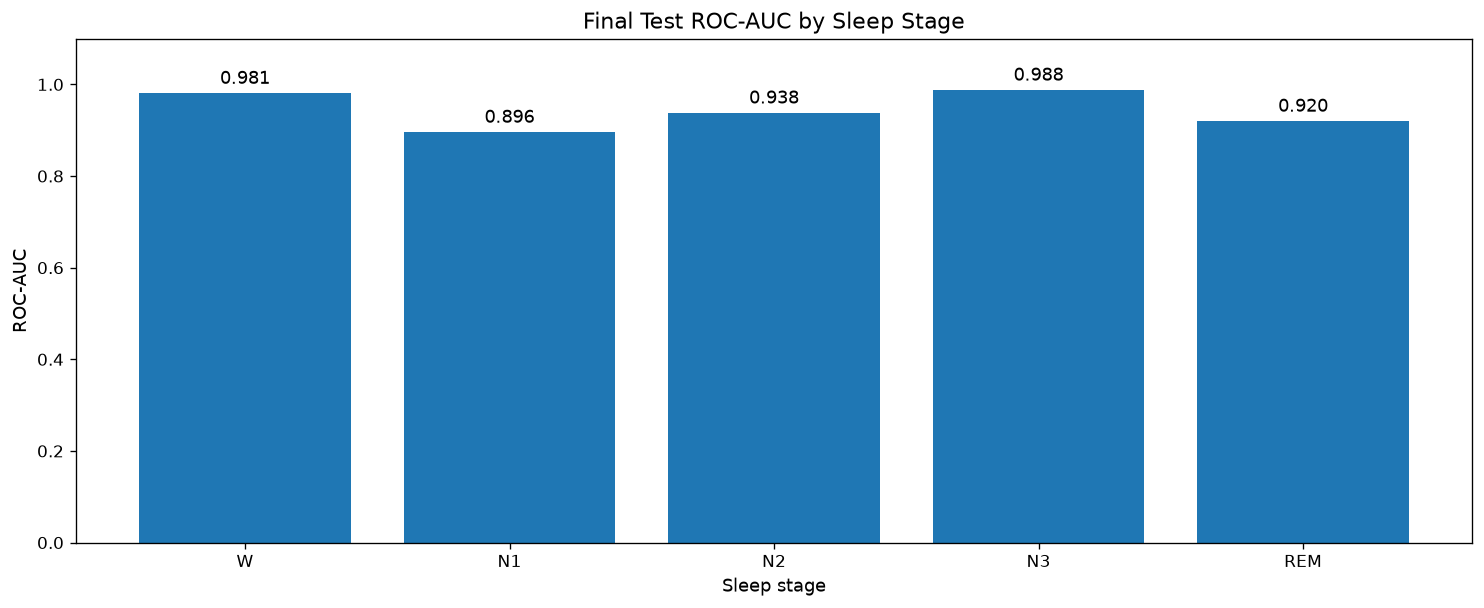

In [35]:
fig, ax=plt.subplots(figsize=(12.5,5.2))
b=ax.bar(auc.Stage, auc['ROC-AUC'])
ax.set_ylim(0,1.1); ax.set_ylabel('ROC-AUC'); ax.set_xlabel('Sleep stage'); ax.set_title('Final Test ROC-AUC by Sleep Stage')
for bar,v in zip(b,auc['ROC-AUC']): ax.text(bar.get_x()+bar.get_width()/2,v+.02,f'{v:.3f}',ha='center')
finish('fig20_per_stage_auc')

## Figure 21 — Final test performance summary

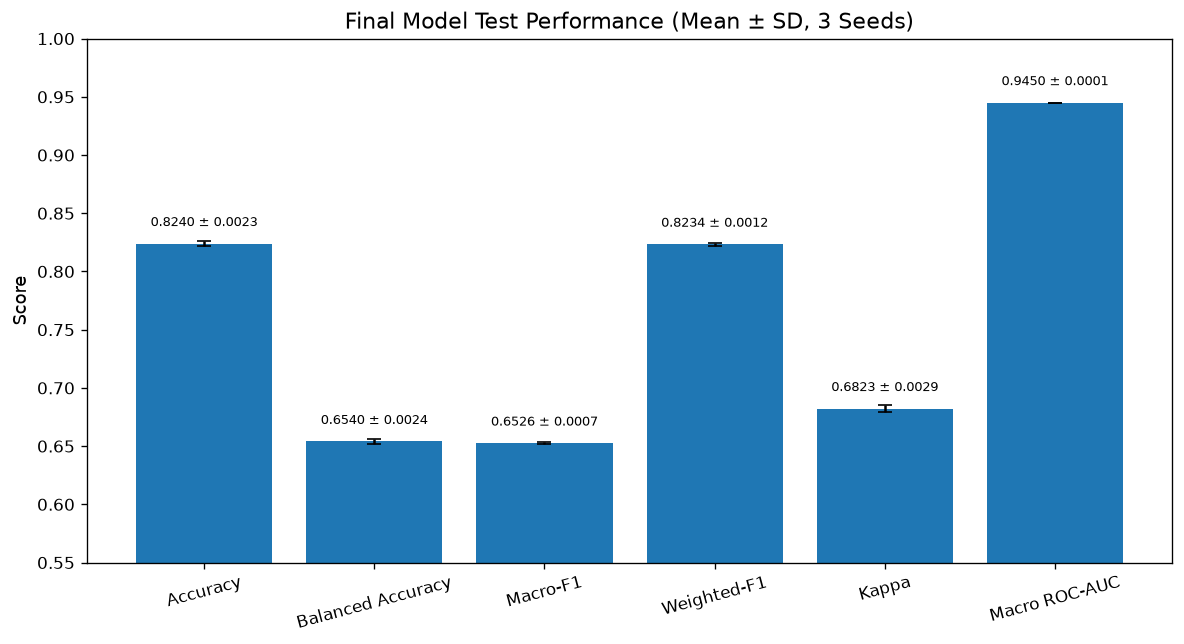

In [36]:
final_means=pd.Series({
    'Accuracy':.8240, 'Balanced Accuracy':.6540, 'Macro-F1':.6526, 'Weighted-F1':.8234, 'Kappa':.6823, 'Macro ROC-AUC':.9450
})
final_std=pd.Series({
    'Accuracy':.0023, 'Balanced Accuracy':.0024, 'Macro-F1':.0007, 'Weighted-F1':.0012, 'Kappa':.0029, 'Macro ROC-AUC':.0001
})
fig, ax=plt.subplots(figsize=(10,5.5))
x=np.arange(len(final_means))
ax.bar(x, final_means.values, yerr=final_std.values, capsize=4)
ax.set_xticks(x, final_means.index, rotation=15); ax.set_ylim(.55,1.0); ax.set_ylabel('Score'); ax.set_title('Final Model Test Performance (Mean ± SD, 3 Seeds)')
for i,(v,s) in enumerate(zip(final_means.values,final_std.values)): ax.text(i,v+.015,f'{v:.4f} ± {s:.4f}',ha='center',fontsize=8)
finish('fig21_final_test_metric_summary')

## Figure 22 — Confusion matrix (Seed 42)

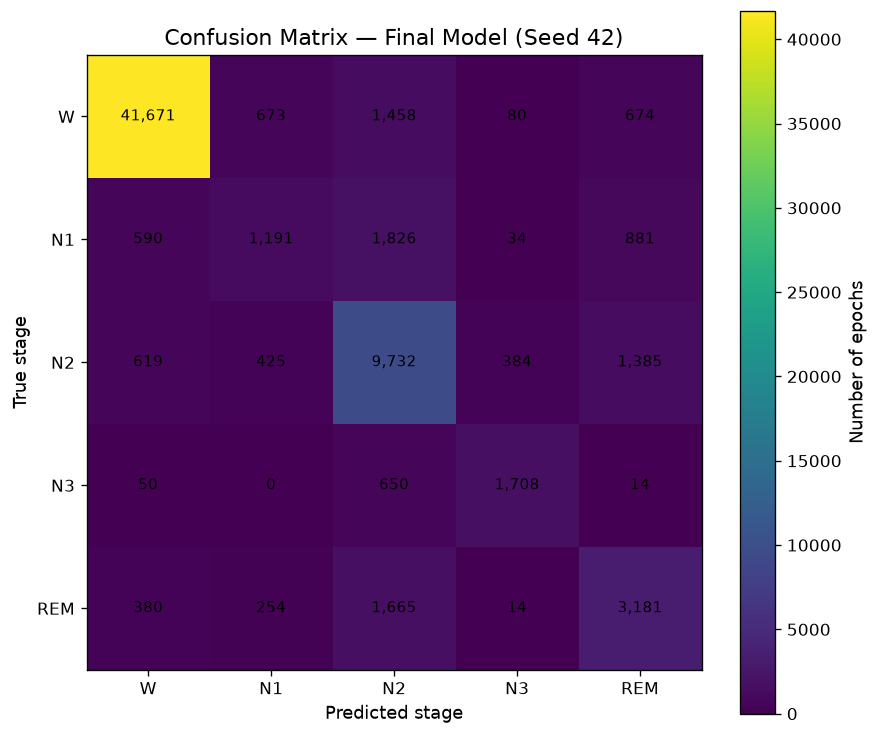

In [37]:
cm=np.array([[41671, 673, 1458, 80, 674],
              [590, 1191, 1826, 34, 881],
              [619, 425, 9732, 384, 1385],
              [50, 0, 650, 1708, 14],
              [380, 254, 1665, 14, 3181]])
fig, ax=plt.subplots(figsize=(7.5,6.5))
im=ax.imshow(cm, aspect='equal')
ax.set_xticks(range(5), STAGES); ax.set_yticks(range(5), STAGES)
ax.set_xlabel('Predicted stage'); ax.set_ylabel('True stage'); ax.set_title('Confusion Matrix — Final Model (Seed 42)')
fig.colorbar(im, ax=ax, label='Number of epochs')
for i in range(5):
    for j in range(5): ax.text(j,i,f'{cm[i,j]:,}',ha='center',va='center',fontsize=9)
finish('fig22_confusion_matrix_counts')

## Figure 23 — Row-normalized confusion matrix

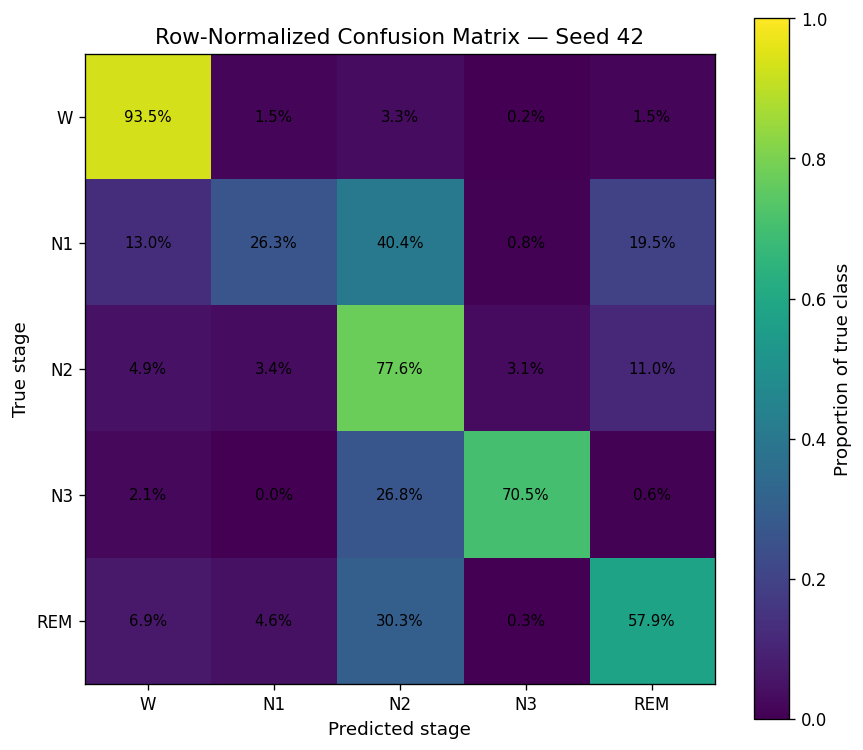

In [26]:
cm_norm=cm/cm.sum(axis=1,keepdims=True)
fig, ax=plt.subplots(figsize=(7.5,6.5))
im=ax.imshow(cm_norm, vmin=0, vmax=1, aspect='equal')
ax.set_xticks(range(5), STAGES); ax.set_yticks(range(5), STAGES)
ax.set_xlabel('Predicted stage'); ax.set_ylabel('True stage'); ax.set_title('Row-Normalized Confusion Matrix — Seed 42')
fig.colorbar(im, ax=ax, label='Proportion of true class')
for i in range(5):
    for j in range(5): ax.text(j,i,f'{100*cm_norm[i,j]:.1f}%',ha='center',va='center',fontsize=9)
finish('fig23_confusion_matrix_normalized')

## Figure 24 — Most frequent misclassifications

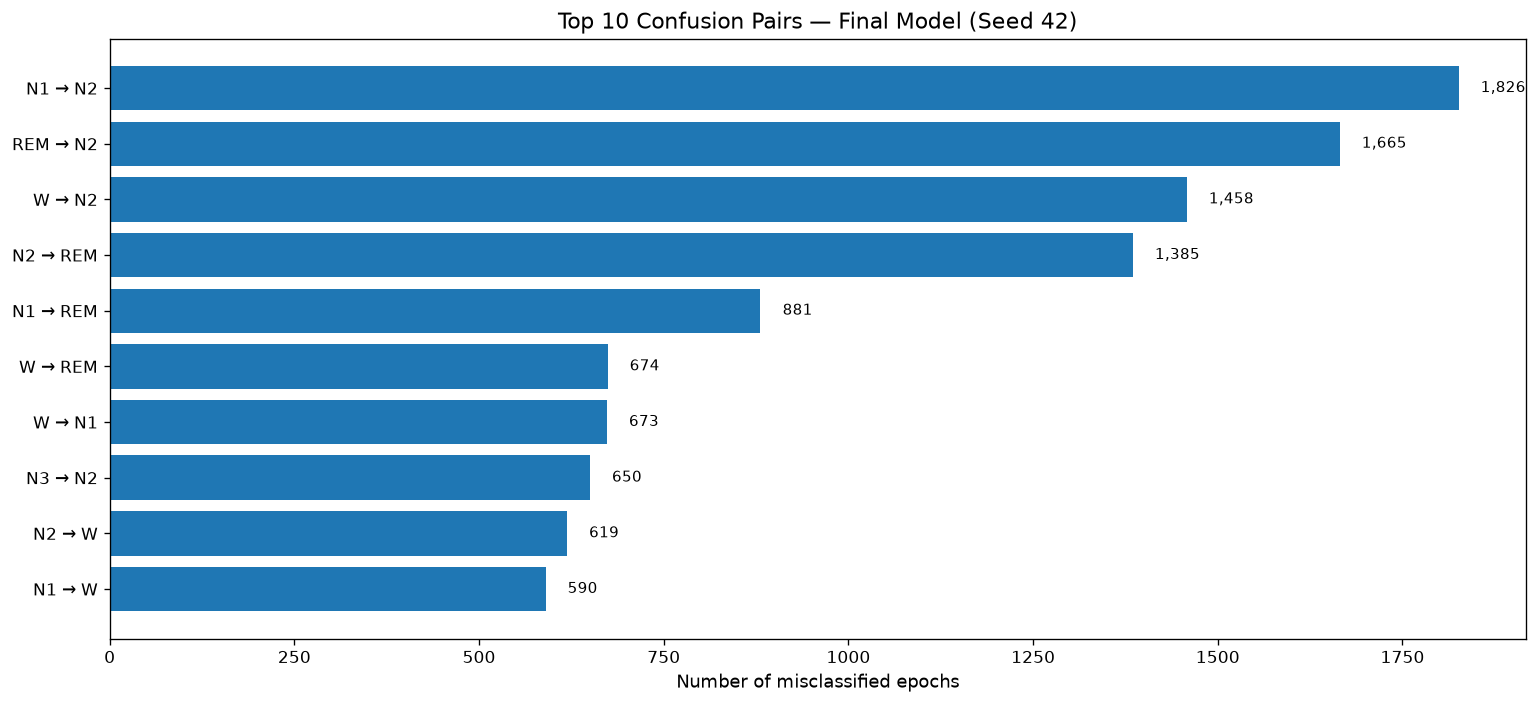

In [47]:
pairs=[]
for i,t in enumerate(STAGES):
    for j,p in enumerate(STAGES):
        if i!=j: pairs.append((f'{t} → {p}', int(cm[i,j])))
pair_df=pd.DataFrame(pairs, columns=['Error','Count']).sort_values('Count', ascending=False).head(10).sort_values('Count')
fig, ax=plt.subplots(figsize=(13,6))
b=ax.barh(pair_df.Error, pair_df.Count)
ax.set_xlabel('Number of misclassified epochs'); ax.set_title('Top 10 Confusion Pairs — Final Model (Seed 42)')
for bar,v in zip(b,pair_df.Count): ax.text(v+30,bar.get_y()+bar.get_height()/2,f'{v:,}',va='center',fontsize=9)
finish('fig24_top_confusion_pairs')

## Figure 25 — Class prevalence versus F1

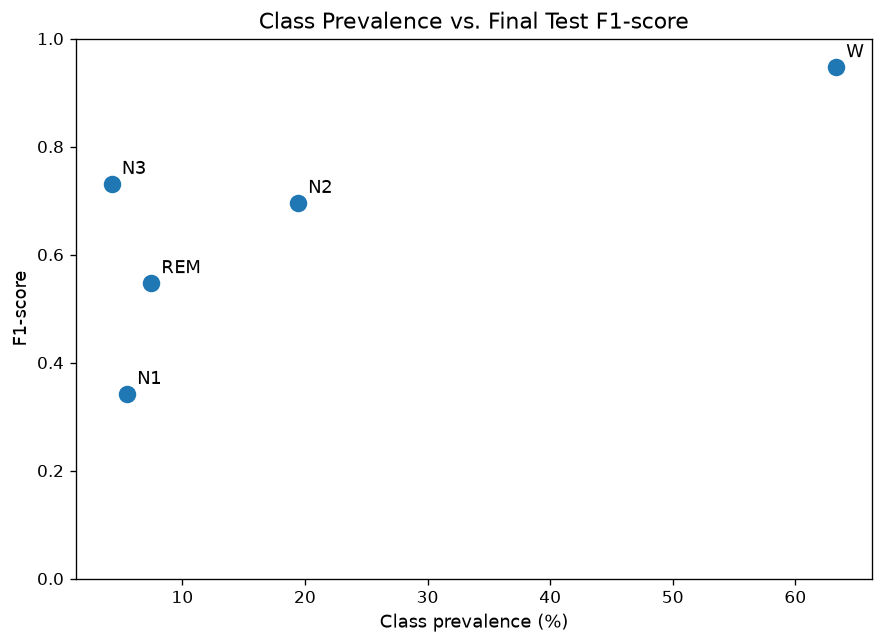

In [48]:
prevalence=(df.target_stage.value_counts(normalize=True).reindex(STAGES)*100)
fig, ax=plt.subplots(figsize=(7.5,5.5))
ax.scatter(prevalence.values, per_class.F1.values, s=90)
for st,xv,yv in zip(STAGES,prevalence.values,per_class.F1.values): ax.annotate(st,(xv,yv),xytext=(6,6),textcoords='offset points')
ax.set_xlabel('Class prevalence (%)'); ax.set_ylabel('F1-score'); ax.set_ylim(0,1); ax.set_title('Class Prevalence vs. Final Test F1-score')
finish('fig25_prevalence_vs_f1')

## Figure 26 — Final model architecture schematic

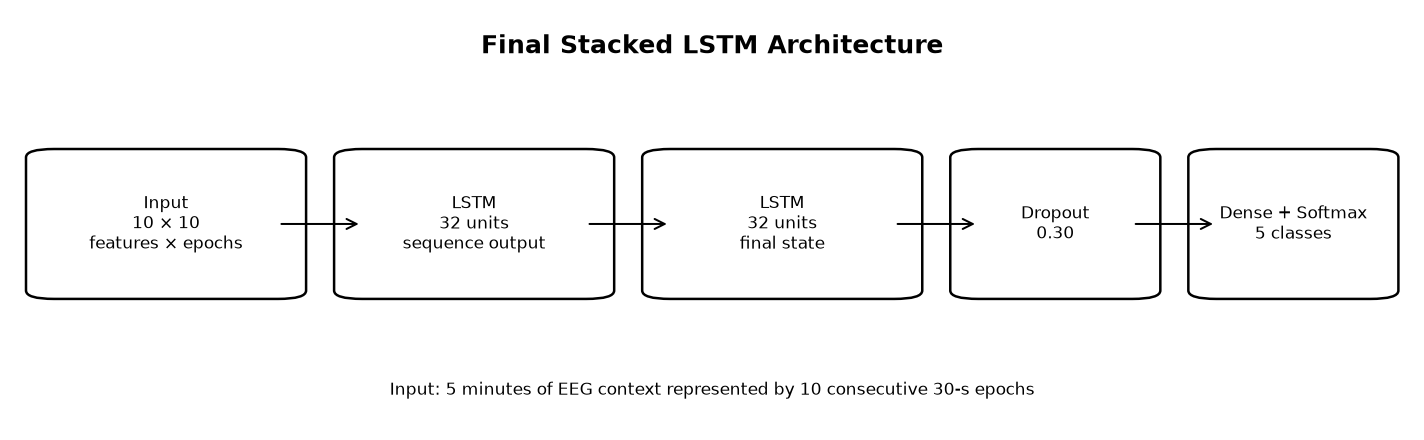

In [49]:
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
fig, ax=plt.subplots(figsize=(12,3.8))
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
boxes=[
    (0.03,0.33,0.16,0.32,'Input\n10 × 10\nfeatures × epochs'),
    (0.25,0.33,0.16,0.32,'LSTM\n32 units\nsequence output'),
    (0.47,0.33,0.16,0.32,'LSTM\n32 units\nfinal state'),
    (0.69,0.33,0.11,0.32,'Dropout\n0.30'),
    (0.86,0.33,0.11,0.32,'Dense + Softmax\n5 classes')
]
for x,y,w,h,text in boxes:
    patch=FancyBboxPatch((x,y),w,h,boxstyle='round,pad=0.02',fill=False,linewidth=1.5)
    ax.add_patch(patch); ax.text(x+w/2,y+h/2,text,ha='center',va='center',fontsize=10)
for a,b in zip(boxes[:-1],boxes[1:]):
    x1=a[0]+a[2]; y1=a[1]+a[3]/2; x2=b[0]; y2=b[1]+b[3]/2
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle='->',mutation_scale=15,linewidth=1.2))
ax.text(0.5,0.90,'Final Stacked LSTM Architecture',ha='center',fontsize=15,fontweight='bold')
ax.text(0.5,0.08,'Input: 5 minutes of EEG context represented by 10 consecutive 30-s epochs',ha='center',fontsize=10)
finish('fig26_final_model_architecture')

## Figure 27 — End-to-end methodology pipeline

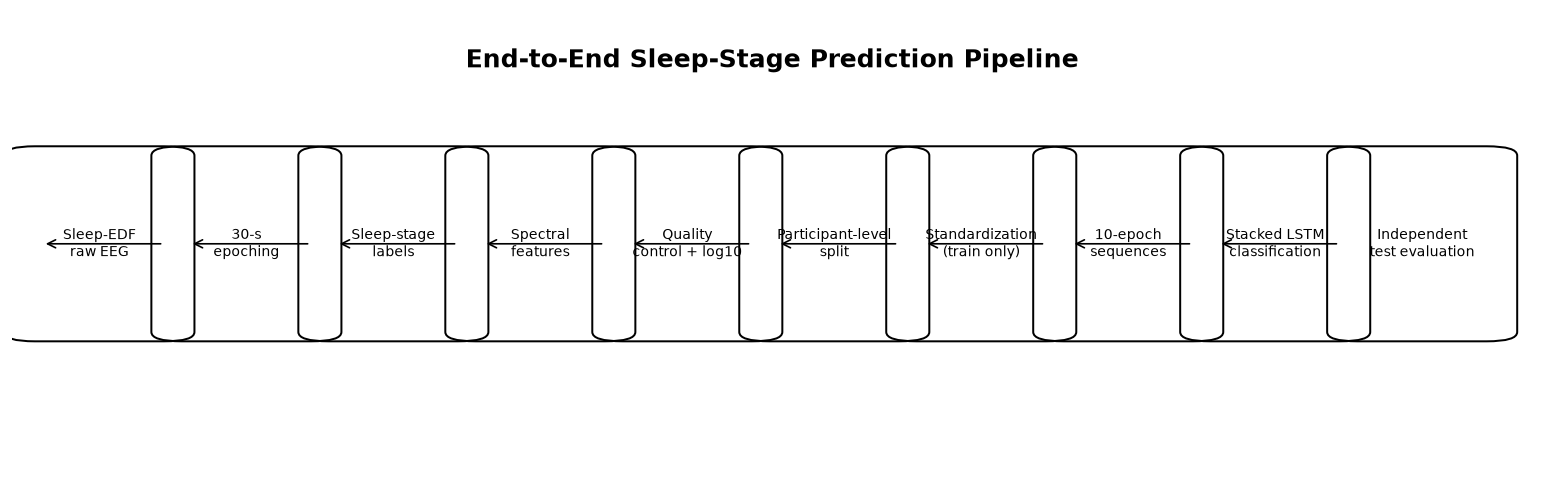

In [59]:
fig, ax=plt.subplots(figsize=(13,4.2)); ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
steps=[
    'Sleep-EDF\nraw EEG', '30-s\nepoching', 'Sleep-stage\nlabels', 'Spectral\nfeatures', 'Quality\ncontrol + log10', 'Participant-level\nsplit', 'Standardization\n(train only)', '10-epoch\nsequences', 'Stacked LSTM\nclassification', 'Independent\ntest evaluation'
]
xs=np.linspace(.015,.885,len(steps)); w=.085; h=.38; y=.31
for x,text in zip(xs,steps):
    patch=FancyBboxPatch((x,y),w,h,boxstyle='round,pad=0.02',fill=False,linewidth=1.2); ax.add_patch(patch)
    ax.text(x+w/2,y+h/2,text,ha='center',va='center',fontsize=8.5)
for x in xs[:-1]: ax.add_patch(FancyArrowPatch((x+w,y+h/2),(x+.005,y+h/2),arrowstyle='->',mutation_scale=12,linewidth=1))
ax.text(.5,.88,'End-to-End Sleep-Stage Prediction Pipeline',ha='center',fontsize=15,fontweight='bold')
finish('fig27_methodology_pipeline')

## Optional Figure 28 — Training curves from saved history files

This cell looks for `history_seed42.csv`, `history_seed123.csv`, or `history_seed456.csv` in the notebook directory. If none exists, it prints a message and does not create a misleading figure.

In [60]:
history_files=sorted(DATA_DIR.glob('history_seed*.csv'))
if history_files:
    fig, ax=plt.subplots(figsize=(9,5.5))
    for hf in history_files:
        h=pd.read_csv(hf)
        if 'val_macro_f1' in h.columns:
            ax.plot(h.index+1,h['val_macro_f1'],label=hf.stem)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Macro-F1'); ax.set_title('Validation Macro-F1 During Training'); ax.legend()
    finish('fig28_training_validation_macrof1')
else:
    print('No history_seed*.csv files found. Training-curve figure skipped.')

No history_seed*.csv files found. Training-curve figure skipped.


## Optional Figure 29 — ROC curves from saved predictions

A true ROC curve requires per-epoch ground-truth labels and predicted probabilities. This section looks for `test_predictions.csv` with `y_true` and `prob_*` columns.

In [61]:
pred_file=DATA_DIR/'test_predictions.csv'
if pred_file.exists():
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize
    pred=pd.read_csv(pred_file)
    prob_cols=[f'prob_{st}' for st in STAGES]
    if {'y_true',*prob_cols}.issubset(pred.columns):
        y_true=label_binarize(pred['y_true'], classes=STAGES)
        fig, ax=plt.subplots(figsize=(7.5,6.5))
        for i,st in enumerate(STAGES):
            fpr,tpr,_=roc_curve(y_true[:,i],pred[f'prob_{st}'])
            ax.plot(fpr,tpr,label=f'{st} (AUC={auc(fpr,tpr):.3f})')
        ax.plot([0,1],[0,1],linestyle='--',linewidth=1)
        ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate'); ax.set_title('One-vs-Rest ROC Curves — Final Test Set'); ax.legend()
        finish('fig29_roc_curves_one_vs_rest')
    else:
        print('test_predictions.csv found, but required columns are missing. ROC figure skipped.')
else:
    print('No test_predictions.csv found. True ROC curves require saved probabilities; figure skipped.')

No test_predictions.csv found. True ROC curves require saved probabilities; figure skipped.


## Recommended figures for the paper

For the main paper, the strongest compact set is usually **Figures 1, 4, 8, 12–15, 18–20, 23, 25, and 26–27**. The remaining figures are useful for supplementary material, the thesis, or reviewer requests.

The notebook intentionally separates **data-derived figures** from **reported-experiment figures** and refuses to invent training curves or ROC curves when the necessary underlying files are unavailable.